In [16]:
import polars as pl
import datetime as dt

min_momentum = 15
min_holding = 2400
vol_stdev = 2
mom_pct = 0.2
    
lf = (
    pl.scan_parquet('stables-1m.parquet')
    .sort(['symbol','ts'])
    .select(
        pl.col('ts'), pl.col('symbol'),
        # rolling volume z-score
        vol=(pl.col('quote_volume') - pl.col('quote_volume').rolling_mean(24*60).over('symbol')) / pl.col('quote_volume').rolling_std(24*60).over('symbol'),
        # forward arithmetic returns
        fwd=pl.col('close').pct_change(-1 * min_holding).over('symbol'),
        # momentum
        mom=pl.col('close').pct_change(min_momentum).over('symbol'),
    )
    .filter((pl.col('mom') >= mom_pct) & (pl.col('vol') > vol_stdev))
)

(
    lf.group_by_dynamic('ts', every=f'{min_holding}m', group_by='symbol')
    .last()
    .with_columns(
        # Convert to "2023-01-01 14:30:00" string format
        ts = pl.col('ts').dt.strftime("%Y-%m-%d %H:%M:%S")
    )
    .collect()
    .write_csv('trades.csv')
)

In [35]:
import polars as pl
import datetime as dt

min_momentum = 15
min_holding = 2400
vol_stdev = 2
mom_pct = 0.2

def apply_lockout(df: pl.DataFrame) -> pl.DataFrame:
    # Logic remains the same
    timestamps = df["ts"].to_numpy()
    keep_mask = [False] * len(timestamps)
    last_exit_time = 0
    holding_ns = min_holding * 60 * 1_000_000_000
    
    for i, current_ts in enumerate(timestamps.view("int64")):
        if current_ts >= last_exit_time:
            keep_mask[i] = True
            last_exit_time = current_ts + holding_ns
            
    return df.filter(keep_mask)

# 1. Build the base lazy plan
lf = (
    pl.scan_parquet('stables-1m.parquet')
    .sort(['symbol', 'ts'])
    .select(
        pl.col('ts'), pl.col('symbol'),
        # rolling volume z-score
        vol=(pl.col('quote_volume') - pl.col('quote_volume').rolling_mean(24*60).over('symbol')) / pl.col('quote_volume').rolling_std(24*60).over('symbol'),
        # forward arithmetic returns
        fwd=pl.col('close').pct_change(-min_holding).over('symbol'),
        fwd_high=(
            pl.col("high")
            .shift(-min_holding)
            .rolling_max(window_size=min_holding)
            .over("symbol") / pl.col("close") - 1
        ),
        fwd_low=(
            pl.col("low")
            .shift(-min_holding)
            .rolling_min(window_size=min_holding)
            .over("symbol") / pl.col("close") - 1
        ),
        # momentum
        mom=pl.col('close').pct_change(min_momentum).over('symbol'),
    )
    .with_columns(
        active=(pl.col('mom') >= mom_pct) & (pl.col('vol') > vol_stdev)
    )
    .filter(
        (pl.col('active')) & 
        (pl.col('active').shift(1).over('symbol').fill_null(False).not_())
    )
)

current_schema = lf.schema
df = (
    lf
    .group_by("symbol")
    .map_groups(apply_lockout, schema=current_schema)
    .collect()
)

(
    df
    .with_columns(
        ts = pl.col('ts').dt.strftime("%Y-%m-%d %H:%M:%S")
    )
    .write_csv("backtest_results.csv")
)

print(f"Backtest complete. Found {len(df)} valid entries.")

/var/folders/tl/9yq9dyyj1sl6tn4r875nj5ym0000gn/T/ipykernel_67812/664251971.py:57: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  current_schema = lf.schema


Backtest complete. Found 247 valid entries.


statistic,ts,symbol,vol,fwd,fwd_high,fwd_low,mom,active
str,str,str,f64,f64,f64,f64,f64,f64
"""count""","""130""","""130""",130.0,130.0,119.0,119.0,130.0,130.0
"""null_count""","""0""","""0""",0.0,0.0,11.0,11.0,0.0,0.0
"""mean""","""2025-06-04 10:54:40.152000+00:…",null,15.964914,0.274282,0.134596,-0.244427,0.317108,1.0
"""std""",null,null,11.545127,0.226278,0.210601,0.116262,0.229525,null
"""min""","""2023-12-29 09:11:59.999000+00:…","""0GUSDC""",2.176261,0.002369,-0.498397,-0.751479,0.2,1.0
"""25%""","""2025-03-02 17:42:59.999000+00:…",null,5.71966,0.136842,0.023289,-0.306235,0.210468,null
"""50%""","""2025-09-05 07:45:59.999000+00:…",null,12.21771,0.205742,0.077551,-0.227684,0.230961,null
"""75%""","""2025-11-08 15:22:59.999000+00:…",null,25.935483,0.375,0.216216,-0.162393,0.291624,null
"""max""","""2026-04-14 07:48:59.999000+00:…","""币安人生USDC""",37.89008,1.405214,1.084683,-0.018511,1.727744,1.0


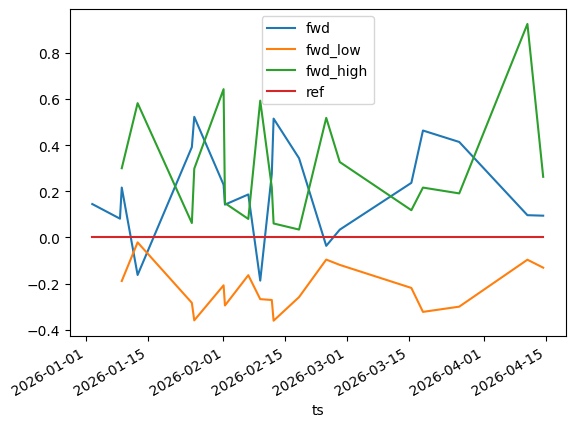

In [38]:
(
    df
    .sort('ts')
    .with_columns(
        ref=pl.lit(0),
    )
    .filter(pl.col('ts').dt.year() == 2026)
    .to_pandas().plot(y=['fwd','fwd_low','fwd_high','ref'], x='ts')
)

dfdescribe()

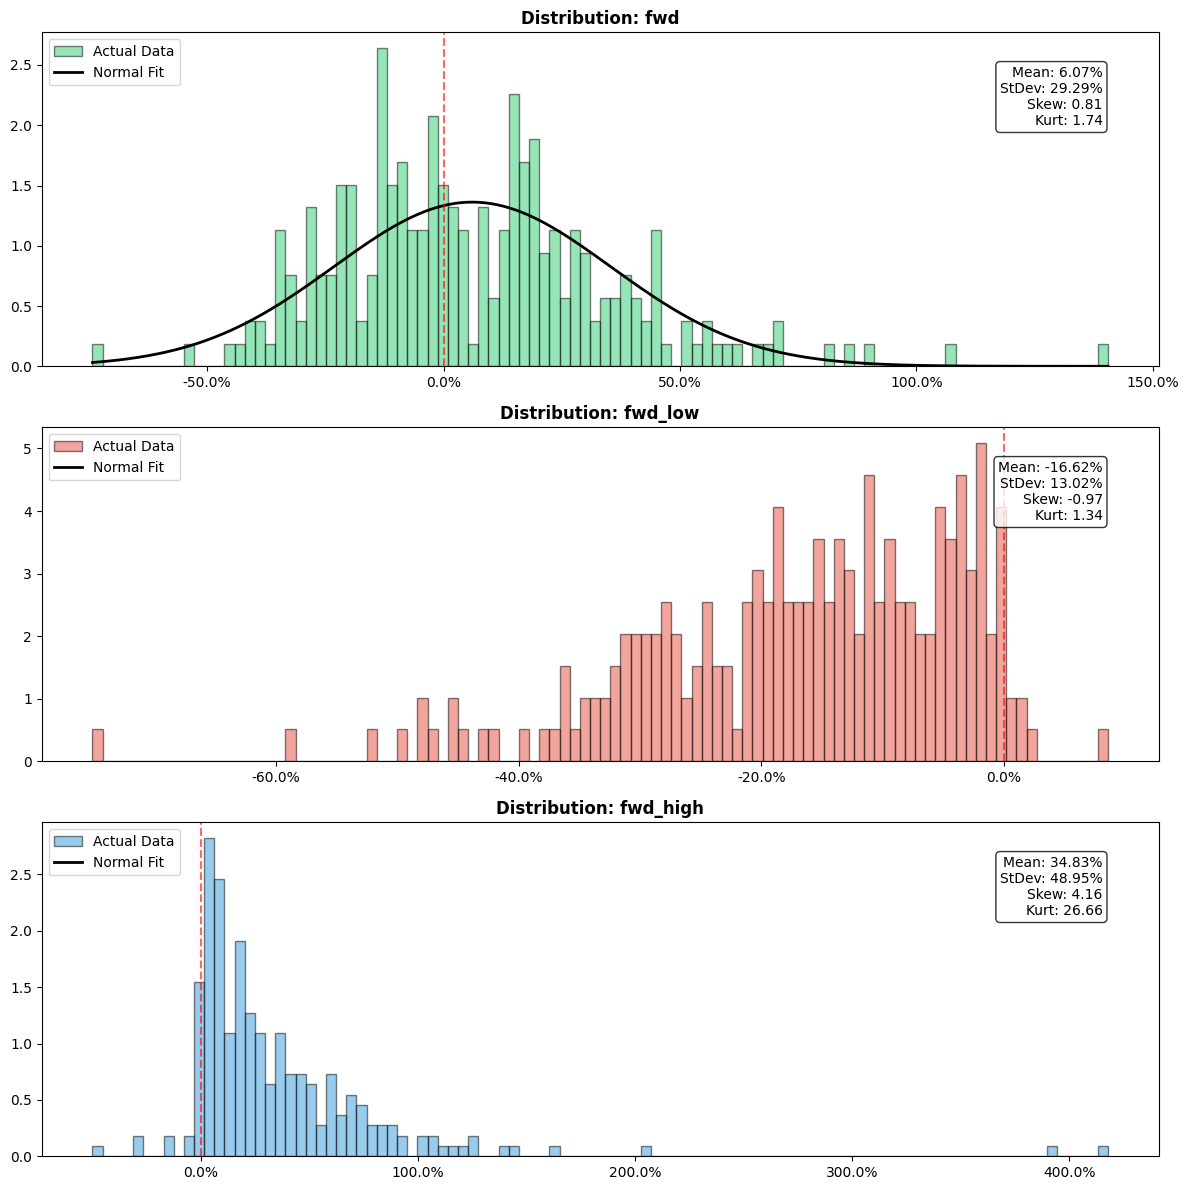

In [51]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_polars_histograms(df: pl.DataFrame, cols: list[str], bins: int = 100):
    """
    Computes statistical moments and plots stacked histograms with 
    Normal PDF overlays using Polars native expressions.
    """
    # 1. Compute all 4 moments for all columns in one pass
    # Polars uses Fisher's definition for Kurtosis (Normal = 0)
    stats = df.select([
        *[pl.col(c).mean().alias(f"{c}_mean") for c in cols],
        *[pl.col(c).std().alias(f"{c}_std") for c in cols],
        *[pl.col(c).skew().alias(f"{c}_skew") for c in cols],
        *[pl.col(c).kurtosis().alias(f"{c}_kurt") for c in cols],
    ]).to_dicts()[0]

    fig, axes = plt.subplots(len(cols), 1, figsize=(12, 4 * len(cols)))
    if len(cols) == 1: axes = [axes]
    
    colors = ['#2ecc71', '#e74c3c', '#3498db'] # Green, Red, Blue

    for i, col in enumerate(cols):
        ax = axes[i]
        # Extract data to numpy for plotting
        data = df[col].to_numpy()
        
        # Get pre-computed moments
        mu, sigma = stats[f"{col}_mean"], stats[f"{col}_std"]
        skew, kurt = stats[f"{col}_skew"], stats[f"{col}_kurt"]

        # Plot Histogram (Density must be True to match PDF scale)
        ax.hist(data, bins=bins, density=True, color=colors[i % 3], 
                edgecolor='black', alpha=0.5, label='Actual Data')

        # Generate Normal Distribution Curve (Bell Curve)
        x = np.linspace(data.min(), data.max(), 500)
        p = norm.pdf(x, mu, sigma)
        ax.plot(x, p, 'k', linewidth=2, label='Normal Fit')

        # Formatting and Annotations
        ax.set_title(f"Distribution: {col}", fontweight='bold')
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
        
        # Stats Box
        stats_text = (
            f"Mean: {mu:.2%}\n"
            f"StDev: {sigma:.2%}\n"
            f"Skew: {skew:.2f}\n"
            f"Kurt: {kurt:.2f}"
        )
        ax.text(0.95, 0.90, stats_text, transform=ax.transAxes, 
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.axvline(0, color='red', linestyle='--', alpha=0.6)
        ax.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

plot_polars_histograms(df, ["fwd", "fwd_low", "fwd_high"])

In [54]:
import polars as pl
import numpy as np

# Assuming 'final_df' is your DataFrame of trades
# We use the raw 'fwd_ret' column to get the mean/std of the strategy.

kelly_stats = df.select([
    # 1. First Moment: Expected Return (Mean)
    pl.col("fwd").mean().alias("mean_ret"),
    # 2. Second Moment: Standard Deviation
    pl.col("fwd").std().alias("std_ret"),
]).to_dicts()[0]

# --- Kelly Calculation ---
mu = kelly_stats["mean_ret"]
sigma = kelly_stats["std_ret"]

# kelly = mu / variance
kelly_fraction = mu / (sigma ** 2)

print(f"Strategy Mean Return: {mu:.2%}")
print(f"Strategy Std Deviation: {sigma:.2%}")
print("-" * 30)
print(f"RAW KELLY ALLOCATION: {kelly_fraction:.2f}x Equity")

Strategy Mean Return: 6.07%
Strategy Std Deviation: 29.29%
------------------------------
RAW KELLY ALLOCATION: 0.71x Equity


In [56]:
import polars as pl
import numpy as np

# Assuming final_df is your collected trades
stats = final_df.select([
    # 1. Mean Return
    pl.col("fwd").mean().alias("mu"),
    
    # 2. Downside Deviation
    # Filter for returns < 0, then compute the standard deviation of those values
    pl.col("fwd")
    .filter(pl.col("fwd") < 0)
    .std()
    .alias("downside_std")
]).to_dicts()[0]

mu = stats["mu"]
sigma_d = stats["downside_std"]

# Sortino Calculation (assuming rf = 0)
sortino = mu / sigma_d if sigma_d > 0 else np.nan

print(f"Mean Return: {mu:.2%}")
print(f"Downside Deviation: {sigma_d:.2%}")
print(f"Sortino Ratio: {sortino:.2f}")

Mean Return: 6.07%
Downside Deviation: 13.07%
Sortino Ratio: 0.46
